In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [49]:
# load the dataset titantic survival dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Perform EDA

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [51]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [52]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [53]:
df.duplicated().value_counts()

False    784
True     107
Name: count, dtype: int64

In [54]:
df.drop_duplicates(inplace=True)

In [55]:
df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    str     
 3   age          678 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     782 non-null    str     
 8   class        784 non-null    category
 9   who          784 non-null    str     
 10  adult_male   784 non-null    bool    
 11  deck         202 non-null    category
 12  embark_town  782 non-null    str     
 13  alive        784 non-null    str     
 14  alone        784 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 77.0 KB


In [56]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [57]:
# too much null values in the deck so drop this one
df.drop(['deck'],axis = 1,inplace=True)

In [58]:
# the columns who is also use less so i think drop that also
df.drop(['who'],axis=1,inplace =True)

In [59]:
df.head()
df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    str     
 3   age          678 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     782 non-null    str     
 8   class        784 non-null    category
 9   adult_male   784 non-null    bool    
 10  embark_town  782 non-null    str     
 11  alive        784 non-null    str     
 12  alone        784 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(4)
memory usage: 69.8 KB


In [60]:
df['embark_town'].value_counts()

embark_town
Southampton    568
Cherbourg      155
Queenstown      59
Name: count, dtype: int64

In [61]:
df['embark_town'].isnull().sum()

np.int64(2)

In [62]:
# can't fill the nan with any value so i think drop these two rows
df.dropna(subset=['embark_town'],axis=0,inplace=True)

In [63]:
df.info()

<class 'pandas.DataFrame'>
Index: 782 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     782 non-null    int64   
 1   pclass       782 non-null    int64   
 2   sex          782 non-null    str     
 3   age          676 non-null    float64 
 4   sibsp        782 non-null    int64   
 5   parch        782 non-null    int64   
 6   fare         782 non-null    float64 
 7   embarked     782 non-null    str     
 8   class        782 non-null    category
 9   adult_male   782 non-null    bool    
 10  embark_town  782 non-null    str     
 11  alive        782 non-null    str     
 12  alone        782 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(4)
memory usage: 69.6 KB


In [64]:
df['age'].isnull().value_counts()

age
False    676
True     106
Name: count, dtype: int64

In [65]:
df['age'] = df['age'].fillna(df['age'].mean())

In [66]:
df.info()

<class 'pandas.DataFrame'>
Index: 782 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     782 non-null    int64   
 1   pclass       782 non-null    int64   
 2   sex          782 non-null    str     
 3   age          782 non-null    float64 
 4   sibsp        782 non-null    int64   
 5   parch        782 non-null    int64   
 6   fare         782 non-null    float64 
 7   embarked     782 non-null    str     
 8   class        782 non-null    category
 9   adult_male   782 non-null    bool    
 10  embark_town  782 non-null    str     
 11  alive        782 non-null    str     
 12  alone        782 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(4)
memory usage: 69.6 KB


In [67]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,no,True


In [68]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'adult_male', 'embark_town', 'alive', 'alone'],
      dtype='str')

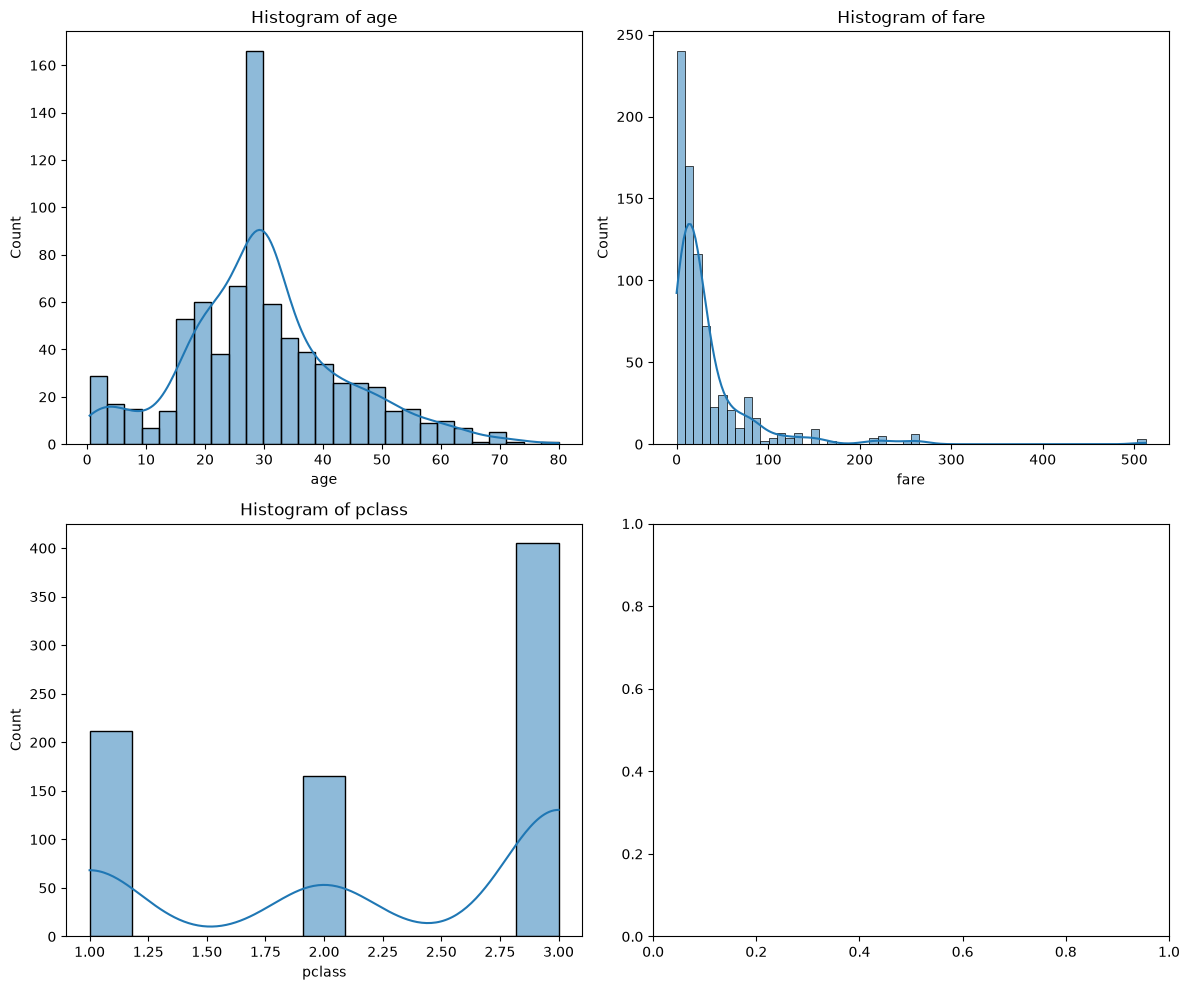

In [69]:
# check the distribution of all the numerica columns
# Create a 2x2 grid for 4 numeric columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Flatten the 2D array into a 1D array of 4 elements
axes_flat = axes.flatten()

# List of columns you want to plot
columns_to_plot = ['age', 'fare', 'pclass']

# Loop through columns and axes simultaneously
for i, col in enumerate(columns_to_plot):
    sns.histplot(data=df, x=col, kde=True, ax=axes_flat[i])
    axes_flat[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [70]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,no,True


In [71]:
df.info()

<class 'pandas.DataFrame'>
Index: 782 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     782 non-null    int64   
 1   pclass       782 non-null    int64   
 2   sex          782 non-null    str     
 3   age          782 non-null    float64 
 4   sibsp        782 non-null    int64   
 5   parch        782 non-null    int64   
 6   fare         782 non-null    float64 
 7   embarked     782 non-null    str     
 8   class        782 non-null    category
 9   adult_male   782 non-null    bool    
 10  embark_town  782 non-null    str     
 11  alive        782 non-null    str     
 12  alone        782 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(4)
memory usage: 69.6 KB


### EDA done, cleaning done now preprocessing

In [72]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,no,True


In [73]:
# Cell 1: preprocessing with one-hot encoding
X = df.drop(columns=['survived', 'alive'])
y = df['survived']

X = pd.get_dummies(
    X,
    columns=['sex', 'class', 'embark_town', 'embarked'],
    drop_first=True
)

X.head()

,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,class_Second,class_Third,embark_town_Queenstown,embark_town_Southampton,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True,False,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False,False,False,False,False
2,3,26.0,0,0,7.9250,False,True,False,False,True,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,False,False,False,False,True,False,True
4,3,35.0,0,0,8.0500,True,True,True,False,True,False,True,False,True


In [74]:
# Cell 2: train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Model Logistic Regression

In [75]:
# Cell 3: model training and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_true=y_test,y_pred=y_pred))
print(confusion_matrix(y_true=y_test, y_pred=y_pred))
print(classification_report(y_true=y_test, y_pred=y_pred))

0.7961783439490446
[[82 11]
 [21 43]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        93
           1       0.80      0.67      0.73        64

    accuracy                           0.80       157
   macro avg       0.80      0.78      0.78       157
weighted avg       0.80      0.80      0.79       157



### Model KNN Classifier

In [76]:
# first do the feature scaling as knn is basically a distance based algorithm and it is sensitive to the scale of the features. If the features are on different scales, the distance calculations can be dominated by the larger scale features, leading to biased results. Therefore, feature scaling is important to ensure that all features contribute equally to the distance calculations.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [77]:
# import the knn model and train it on the scaled data
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)
y_pred_scaled = knn_model.predict(x_test_scaled)

In [78]:
# now do the evaluation metrices
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_true=y_test,y_pred=y_pred_scaled)

0.7770700636942676

In [79]:
confusion_matrix(y_true=y_test,y_pred=y_pred_scaled)

array([[84,  9],
       [26, 38]])

In [80]:
print(classification_report(y_true=y_test,y_pred=y_pred_scaled))

              precision    recall  f1-score   support

           0       0.76      0.90      0.83        93
           1       0.81      0.59      0.68        64

    accuracy                           0.78       157
   macro avg       0.79      0.75      0.76       157
weighted avg       0.78      0.78      0.77       157



### Model Naive Bayes Algorithm

In [81]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)
nb_pred = nb_model.predict(x_test_scaled)


In [82]:
# Cell 4: model evaluation 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_true=y_test, y_pred=nb_pred))
print(confusion_matrix(y_true=y_test, y_pred=nb_pred))
print(classification_report(y_true=y_test, y_pred=nb_pred))

0.802547770700637
[[79 14]
 [17 47]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.84        93
           1       0.77      0.73      0.75        64

    accuracy                           0.80       157
   macro avg       0.80      0.79      0.79       157
weighted avg       0.80      0.80      0.80       157



### Model Decision Tree

In [83]:
# import the model for decision tree
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)

In [84]:
model_dt.fit(x_train_scaled,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [85]:
y_pred_dt = model_dt.predict(x_test_scaled)

In [86]:
accuracy_score(y_test,y_pred_dt)

0.7707006369426752

In [87]:
confusion_matrix(y_test,y_pred_dt)

array([[80, 13],
       [23, 41]])

In [88]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        93
           1       0.76      0.64      0.69        64

    accuracy                           0.77       157
   macro avg       0.77      0.75      0.76       157
weighted avg       0.77      0.77      0.77       157



### Model Support Vector Machine

In [89]:
# import the svm model and train it on the scaled data
from sklearn.svm import SVC
model_svm = SVC(random_state=42)
model_svm.fit(x_train_scaled,y_train)
y_pred_svm = model_svm.predict(x_test_scaled)

In [90]:
# now do the evaluation metrices
print(accuracy_score(y_true=y_test,y_pred=y_pred_svm))
confusion_matrix(y_true=y_test,y_pred=y_pred_svm)
print(classification_report(y_true=y_test,y_pred=y_pred_svm))

0.8089171974522293
              precision    recall  f1-score   support

           0       0.77      0.96      0.86        93
           1       0.90      0.59      0.72        64

    accuracy                           0.81       157
   macro avg       0.84      0.78      0.79       157
weighted avg       0.83      0.81      0.80       157



In [91]:
from sklearn.metrics import accuracy_score

accuracy_scores = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "KNN Classifier": accuracy_score(y_test, y_pred_scaled),
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Support Vector Machine (SVM)": accuracy_score(y_test, y_pred_svm)
}

for name, acc in accuracy_scores.items():
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.7962
KNN Classifier: 0.7771
Naive Bayes: 0.8025
Decision Tree: 0.7707
Support Vector Machine (SVM): 0.8089


## Model Comparison Summary

Here is a comparison of the classification models used in this notebook:

| Algorithm | Accuracy |
|---|---:|
| Logistic Regression | 0.8025 |
| KNN Classifier | 0.7771 |
| Naive Bayes | 0.8025 |
| Decision Tree | 0.7707 |
| Support Vector Machine (SVM) | 0.8089 |

Based on the results, the best model for this case is **Support Vector Machine** because it achieved the highest accuracy.

### now apply the k_fold cross validation on all the models and get the mean score

In [93]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True,Southampton,no,True


In [94]:
# Cell 1: preprocessing with one-hot encoding
X = df.drop(columns=['survived', 'alive'])
y = df['survived']

X = pd.get_dummies(
    X,
    columns=['sex', 'class', 'embark_town', 'embarked'],
    drop_first=True
)

X.head()

,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,class_Second,class_Third,embark_town_Queenstown,embark_town_Southampton,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True,False,True,False,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False,False,False,False,False
2,3,26.0,0,0,7.9250,False,True,False,False,True,False,True,False,True
3,1,35.0,1,0,53.1000,False,False,False,False,False,False,True,False,True
4,3,35.0,0,0,8.0500,True,True,True,False,True,False,True,False,True


In [102]:
# now perform the standerd scaling in the x 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

In [ ]:
# now go for the k_fold_cross_validation inside it automatically train_Test split happens
from sklearn.model_selection import cross_val_score

In [103]:
models = {
    'logistic regression': LogisticRegression(),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'naive bayes': GaussianNB(),
    'decision tree': DecisionTreeClassifier(random_state=42),
    'svm': SVC(random_state=42)
}

In [104]:
avg_score = []

In [105]:
for name, model in models.items():
    scores = cross_val_score(estimator=model, X=x_scaled, y=y, cv=5, scoring='accuracy')
    avg_score.append({
        'model': name,
        'mean_accuracy': np.mean(scores),
    })



In [106]:
for _ in avg_score:
    print(f"Model: {_['model']}, Mean Accuracy: {_['mean_accuracy']:.4f}")

Model: logistic regression, Mean Accuracy: 0.8005
Model: knn, Mean Accuracy: 0.7814
Model: naive bayes, Mean Accuracy: 0.7584
Model: decision tree, Mean Accuracy: 0.7314
Model: svm, Mean Accuracy: 0.7993


after performing the cross validation the logisitc regression model perform better than the svm model